# Fireworks & Air Quality — Machine Learning Models

This notebook builds two models on the global fireworks dataset:

1. **Regression** — Predict PM10 levels given weather conditions and event type
2. **Classification** — Predict whether a night is an event night based on air quality and weather

Both models use data from all events and cities combined.

**Dataset:** `fireworks_events_2013_2025.db`  
**Author:** Franziska Tannert

## 0. Setup

⚠️ **Set your database path here before running anything else.**

In [13]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.metrics import (
    mean_squared_error, r2_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay
)
from sklearn.preprocessing import LabelEncoder
from sklearn.inspection import permutation_importance
import xgboost as xgb

import warnings
warnings.filterwarnings('ignore')

# ── Set your path here ────────────────────────────────────────────────────────
DB = r'C:\Silvesterprojekt\fireworks_events_2013_2025.db'
# ─────────────────────────────────────────────────────────────────────────────

conn = sqlite3.connect(DB)
print(f'Connected: {DB}')

sns.set_theme(style='darkgrid', palette='muted')
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (12, 5)

Connected: C:\Silvesterprojekt\fireworks_events_2013_2025.db


In [14]:
tables = pd.read_sql("SELECT name FROM sqlite_master WHERE type='table'", conn)
print(tables)

                                     name
0  silvester_airquality_weather_2013_2025
1                silvester_soil_2013_2025
2                  fixed_events_2013_2025
3               variable_events_2013_2025
4                reference_days_2013_2025
5               extended_cities_2013_2025
6               city_population_2013_2025
7            country_population_2013_2025
8                 elevation_all_locations


## 1. Data Loading

We combine four tables that all contain event and reference night data:
- `silvester_airquality_weather_2013_2025` — New Year's Eve, 155 capitals
- `fixed_events_2013_2025` — Independence Day, Bastille Day, etc.
- `variable_events_2013_2025` — Diwali, Chinese New Year, Eid, etc.
- `extended_cities_2013_2025` — 153 additional cities

We also join reference days from `reference_days_2013_2025` so the model
sees both event nights and baseline nights.

The target variable for regression is `a_pm10`.
The target variable for classification is `is_event_day` (1 = event night, 0 = reference night).

In [15]:
# ── Inspect database tables ────────────────────────────────────────────────────
cursor = conn.cursor()
cursor.execute("SELECT name FROM sqlite_master WHERE type='table';")
tables = cursor.fetchall()
print("Tables in database:", tables)

# ── Weather and air quality features we want to use ───────────────────────────
WEATHER_FEATURES = [
    'w_temperature_2m',
    'w_relative_humidity_2m',
    'w_precipitation',
    'w_wind_speed_10m',
    'w_wind_gusts_10m',
    'w_cloudcover',
    'w_surface_pressure',
    'w_boundary_layer_height',
    'w_snow_depth',
]

AIR_FEATURES = [
    'a_pm2_5',
    'a_nitrogen_dioxide',
    'a_sulphur_dioxide',
    'a_carbon_monoxide',
    'a_ozone',
]

META = ['event', 'country', 'city', 'year', 'is_event_day']
TARGET = 'a_pm10'

ALL_COLS = META + [TARGET] + WEATHER_FEATURES + AIR_FEATURES

# ── Load fixed events ─────────────────────────────────────────────────────────
fix = pd.read_sql(f"""
    SELECT {', '.join(ALL_COLS)}
    FROM fixed_events_2013_2025
    WHERE a_pm10 IS NOT NULL
""", conn)

# ── Load variable events ──────────────────────────────────────────────────────
var = pd.read_sql(f"""
    SELECT {', '.join(ALL_COLS)}
    FROM variable_events_2013_2025
    WHERE a_pm10 IS NOT NULL
""", conn)

# ── Load silvester (add event column) ─────────────────────────────────────────
sil_cols = [c for c in ALL_COLS if c not in ('event', 'is_event_day')]
sil = pd.read_sql(f"""
    SELECT {', '.join(sil_cols)}
    FROM silvester_airquality_weather_2013_2025
    WHERE a_pm10 IS NOT NULL
""", conn)
sil['event'] = 'new_years_eve'
sil['is_event_day'] = 1

# ── Load reference days ───────────────────────────────────────────────────────
# Reference days have no is_event_day column — we set it to 0
ref_cols = [c for c in ALL_COLS if c != 'is_event_day']
ref = pd.read_sql(f"""
    SELECT {', '.join(ref_cols)}
    FROM reference_days_2013_2025
    WHERE a_pm10 IS NOT NULL
""", conn)
ref['is_event_day'] = 0

# ── Load extended cities ──────────────────────────────────────────────────────
ext_cols = [c.replace('event', 'category') if c == 'event' else c for c in ALL_COLS]
ext = pd.read_sql(f"""
    SELECT category as event, country, city, year,
           CASE WHEN data_type = 'event' THEN 1 ELSE 0 END as is_event_day,
           {', '.join([TARGET] + WEATHER_FEATURES + AIR_FEATURES)}
    FROM extended_cities_2013_2025
    WHERE a_pm10 IS NOT NULL
""", conn)

# ── Combine all tables ────────────────────────────────────────────────────────
df = pd.concat([fix, var, sil, ref, ext], ignore_index=True)

print(f'Total rows loaded: {len(df):,}')
print(f'Event nights:      {df["is_event_day"].sum():,}')
print(f'Reference nights:  {(df["is_event_day"] == 0).sum():,}')
print(f'Unique events:     {df["event"].nunique()}')
print(f'Unique cities:     {df["city"].nunique()}')
df.head(3)

Tables in database: [('silvester_airquality_weather_2013_2025',), ('silvester_soil_2013_2025',), ('fixed_events_2013_2025',), ('variable_events_2013_2025',), ('reference_days_2013_2025',), ('extended_cities_2013_2025',), ('city_population_2013_2025',), ('country_population_2013_2025',), ('elevation_all_locations',)]
Total rows loaded: 82,229
Event nights:      27,485
Reference nights:  54,744
Unique events:     31
Unique cities:     336


,event,country,city,year,is_event_day,a_pm10,w_temperature_2m,w_relative_humidity_2m,w_precipitation,w_wind_speed_10m,w_wind_gusts_10m,w_cloudcover,w_surface_pressure,w_boundary_layer_height,w_snow_depth,a_pm2_5,a_nitrogen_dioxide,a_sulphur_dioxide,a_carbon_monoxide,a_ozone
0,australia_day,Australia,Sydney,2023,0,14.2,22.1,89,0.0,9.5,24.5,3,1002.1,425.0,0.0,8.0,32.0,5.2,99.0,26.0
1,australia_day,Australia,Sydney,2023,0,15.5,21.5,94,0.0,11.8,20.5,8,1002.7,255.0,0.0,9.1,35.0,5.1,113.0,18.0
2,australia_day,Australia,Sydney,2023,0,17.5,21.4,95,0.0,10.1,20.9,5,1003.4,225.0,0.0,10.6,36.9,5.3,130.0,14.0


## 2. Data Preparation

Before training a model, we need to:
1. Handle missing values — some air quality variables are sparse for remote regions
2. Encode categorical variables (event name, country, city) as numbers
3. Define the final feature matrix X and target vector y

We use **median imputation** for missing values — simple and robust for this dataset.

For categorical variables we use **Label Encoding** — this assigns each unique
string a number. For tree-based models (Random Forest, XGBoost) this works well.

In [16]:
# ── Check missing values ──────────────────────────────────────────────────────
print('Missing values per column (%):')
missing = df[WEATHER_FEATURES + AIR_FEATURES + [TARGET]].isnull().mean() * 100
print(missing[missing > 0].sort_values(ascending=False).round(1))

Missing values per column (%):
a_carbon_monoxide          11.4
a_sulphur_dioxide          11.4
w_boundary_layer_height     5.4
w_snow_depth                0.0
dtype: float64


In [17]:
# ── Fill missing values with column median ────────────────────────────────────
# We fill numeric columns with their median.
# This is conservative — it does not introduce fake patterns.
num_cols = WEATHER_FEATURES + AIR_FEATURES
df[num_cols] = df[num_cols].fillna(df[num_cols].median())

# Drop rows where target is still missing (should be none after our SQL filter)
df = df.dropna(subset=[TARGET])

print(f'Rows after cleaning: {len(df):,}')
print(f'Missing values remaining: {df[num_cols + [TARGET]].isnull().sum().sum()}')

Rows after cleaning: 82,229
Missing values remaining: 0


In [18]:
# ── Encode categorical variables ──────────────────────────────────────────────
# LabelEncoder converts strings to integers, e.g. 'Berlin' -> 42
# Tree-based models handle this well.
le_event   = LabelEncoder()
le_country = LabelEncoder()
le_city    = LabelEncoder()

df['event_enc']   = le_event.fit_transform(df['event'].astype(str))
df['country_enc'] = le_country.fit_transform(df['country'].astype(str))
df['city_enc']    = le_city.fit_transform(df['city'].astype(str))

# ── Final feature list ────────────────────────────────────────────────────────
FEATURES = WEATHER_FEATURES + AIR_FEATURES + ['event_enc', 'country_enc', 'city_enc', 'year']

X = df[FEATURES]
y_reg  = df[TARGET]           # for regression
y_clf  = df['is_event_day']   # for classification

print(f'Feature matrix shape: {X.shape}')
print(f'Features: {FEATURES}')

Feature matrix shape: (82229, 18)
Features: ['w_temperature_2m', 'w_relative_humidity_2m', 'w_precipitation', 'w_wind_speed_10m', 'w_wind_gusts_10m', 'w_cloudcover', 'w_surface_pressure', 'w_boundary_layer_height', 'w_snow_depth', 'a_pm2_5', 'a_nitrogen_dioxide', 'a_sulphur_dioxide', 'a_carbon_monoxide', 'a_ozone', 'event_enc', 'country_enc', 'city_enc', 'year']


## 3. Train/Test Split

We split the data into 80% training and 20% test.

Important: we use `random_state=42` for reproducibility.

We do **not** split by year intentionally here — we want the model to generalize
across cities and events, not across time. A time-based split would be the right
choice if the goal were forecasting future years.

In [19]:
X_train, X_test, y_train_reg, y_test_reg, y_train_clf, y_test_clf = train_test_split(
    X, y_reg, y_clf,
    test_size=0.2,
    random_state=42
)

print(f'Training set:  {len(X_train):,} rows')
print(f'Test set:      {len(X_test):,} rows')
print(f'Event nights in test set: {y_test_clf.sum():,} ({y_test_clf.mean()*100:.1f}%)')

Training set:  65,783 rows
Test set:      16,446 rows
Event nights in test set: 5,544 (33.7%)


## 4. Regression — Predicting PM10

### 4.1 Random Forest Baseline

We start with a Random Forest — a robust baseline that:
- Handles non-linear relationships well
- Is resistant to outliers
- Provides feature importance out of the box
- Requires little tuning to get good results

We evaluate with two metrics:
- **RMSE** (Root Mean Squared Error) — average prediction error in μg/m³
- **R²** — how much variance the model explains (1.0 = perfect, 0 = no better than mean)

In [20]:
rf_reg = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=5,
    n_jobs=-1,
    random_state=42
)

rf_reg.fit(X_train, y_train_reg)

y_pred_rf = rf_reg.predict(X_test)
rmse_rf = np.sqrt(mean_squared_error(y_test_reg, y_pred_rf))
r2_rf   = r2_score(y_test_reg, y_pred_rf)

print(f'Random Forest Regression')
print(f'  RMSE: {rmse_rf:.2f} μg/m³')
print(f'  R²:   {r2_rf:.4f}')

Random Forest Regression
  RMSE: 16.24 μg/m³
  R²:   0.9191


### 4.2 XGBoost

XGBoost is often more accurate than Random Forest, especially on tabular data.
It builds trees sequentially — each tree corrects the errors of the previous one
(gradient boosting). The downside is slightly more hyperparameters to tune.

In [21]:
xgb_reg = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_reg.fit(X_train, y_train_reg)

y_pred_xgb = xgb_reg.predict(X_test)
rmse_xgb = np.sqrt(mean_squared_error(y_test_reg, y_pred_xgb))
r2_xgb   = r2_score(y_test_reg, y_pred_xgb)

print(f'XGBoost Regression')
print(f'  RMSE: {rmse_xgb:.2f} μg/m³')
print(f'  R²:   {r2_xgb:.4f}')

XGBoost Regression
  RMSE: 11.13 μg/m³
  R²:   0.9620


### 4.3 Model Comparison

Both models are evaluated on the same test set. Points close to the dashed
line indicate accurate predictions, scatter around it shows where the model
under- or overestimates.

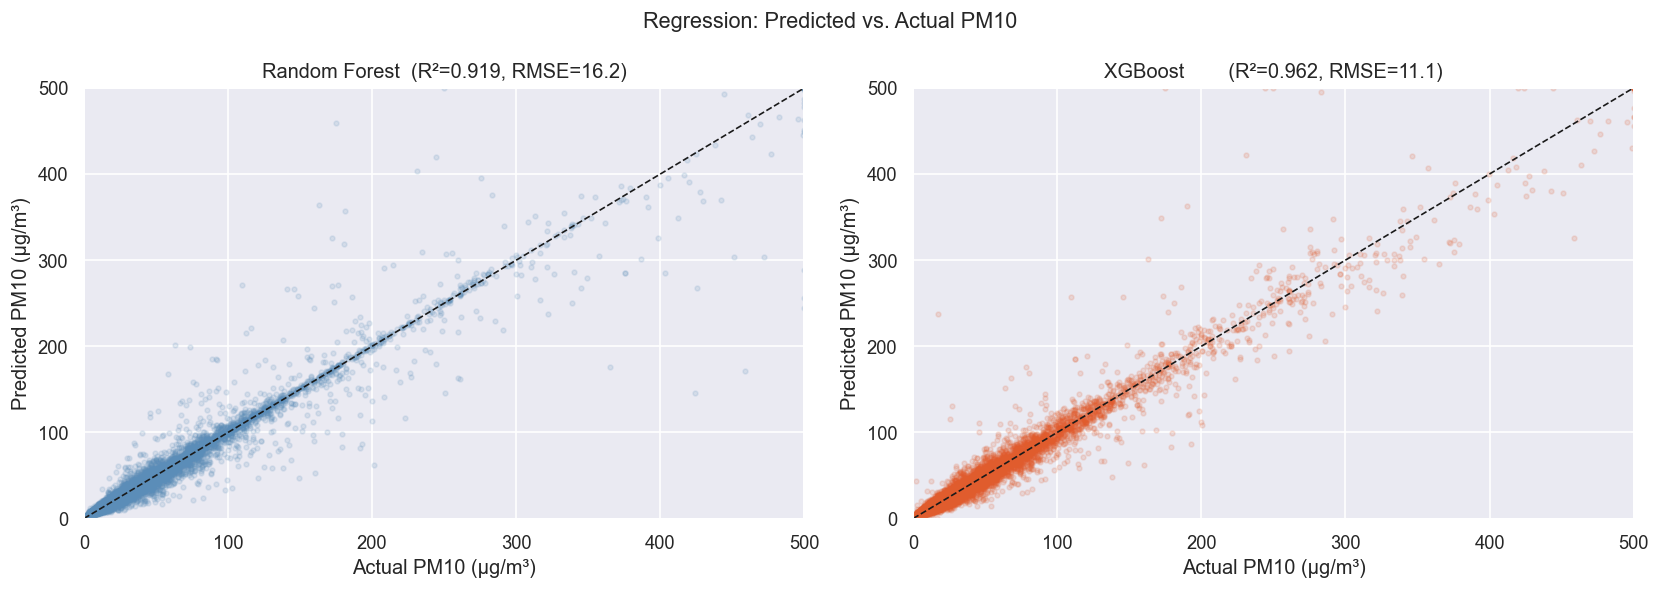

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, y_pred, label, color in [
    (axes[0], y_pred_rf,  f'Random Forest  (R²={r2_rf:.3f}, RMSE={rmse_rf:.1f})', '#5b8db8'),
    (axes[1], y_pred_xgb, f'XGBoost        (R²={r2_xgb:.3f}, RMSE={rmse_xgb:.1f})', '#e05c2d'),
]:
    # Clip predictions to reasonable range for visualization
    y_plot = np.clip(y_pred, 0, 500)
    y_true_plot = np.clip(y_test_reg, 0, 500)

    ax.scatter(y_true_plot, y_plot, alpha=0.15, s=8, color=color)
    ax.plot([0, 500], [0, 500], 'k--', linewidth=1, label='Perfect prediction')
    ax.set_xlabel('Actual PM10 (μg/m³)')
    ax.set_ylabel('Predicted PM10 (μg/m³)')
    ax.set_title(label)
    ax.set_xlim(0, 500)
    ax.set_ylim(0, 500)

plt.suptitle('Regression: Predicted vs. Actual PM10', fontsize=13)
plt.tight_layout()
plt.show()

### 4.4 Feature Importance

Feature importance tells us which variables the model relies on most.
For XGBoost we use the built-in importance score.

This directly answers the question: **what drives PM10 levels?**

⚠️ **Methodological note — data leakage:** PM2.5 and carbon monoxide appear
as the two most important features. This is expected but also a caveat:
both are measured *at the same time* as PM10, not before it. They are
physically correlated with PM10 by definition — fine particles and combustion
products co-occur. This means the model is partly exploiting concurrent
measurements rather than predicting from prior conditions.

For a cleaner causal interpretation, these features should be removed and
the model retrained on weather variables alone. This is addressed in the
next notebook.

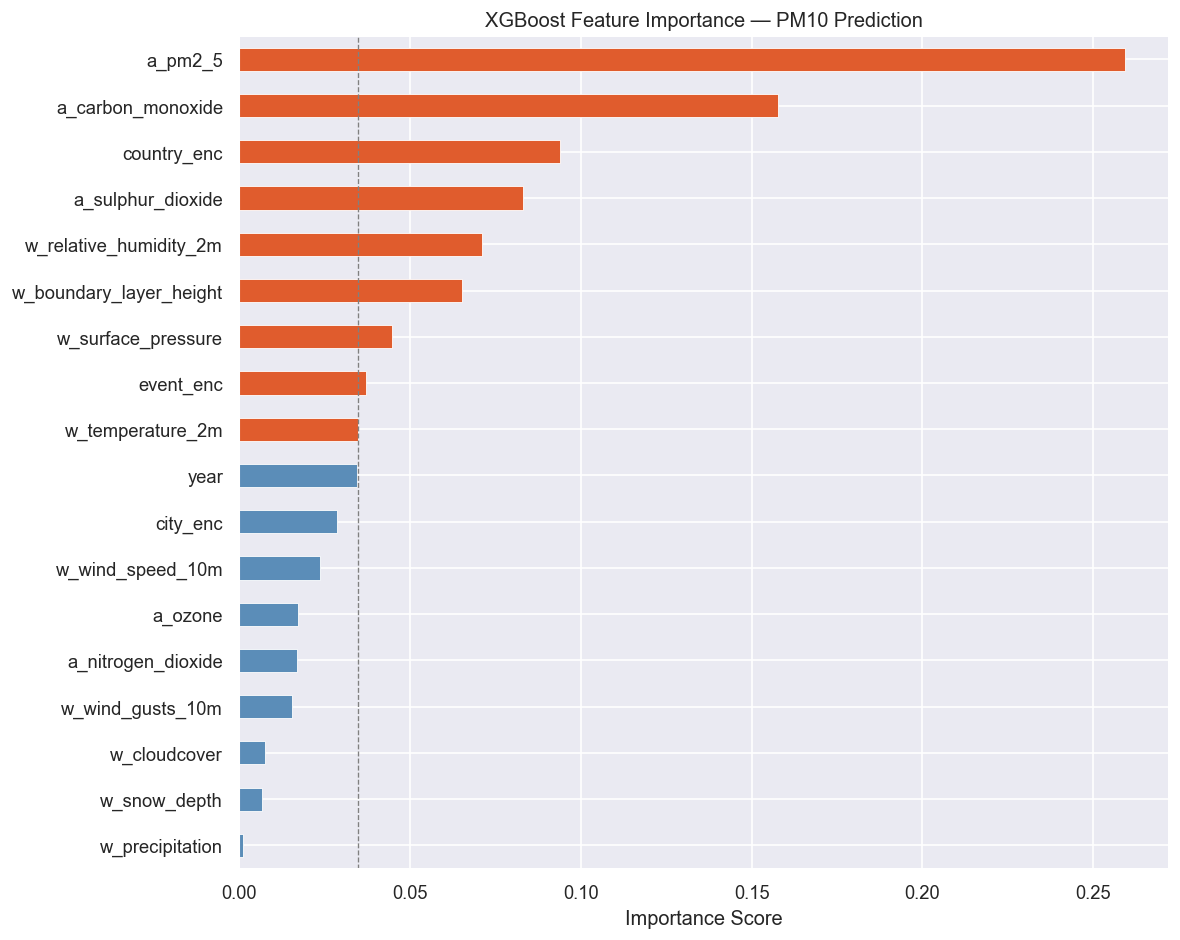


Top 5 features:
a_pm2_5                   0.2591
a_carbon_monoxide         0.1577
country_enc               0.0940
a_sulphur_dioxide         0.0833
w_relative_humidity_2m    0.0711
dtype: float32


In [23]:
# XGBoost feature importance
importance = pd.Series(
    xgb_reg.feature_importances_,
    index=FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e05c2d' if v > importance.median() else '#5b8db8' for v in importance.values]
importance.plot(kind='barh', ax=ax, color=colors, edgecolor='white', linewidth=0.5)
ax.set_title('XGBoost Feature Importance — PM10 Prediction')
ax.set_xlabel('Importance Score')
ax.axvline(importance.median(), color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

print('\nTop 5 features:')
print(importance.tail(5).sort_values(ascending=False).round(4))

### 4.5 Residual Analysis

Residuals are the differences between predicted and actual values.
A good model has residuals that are randomly distributed around zero —
no systematic over- or underprediction.

If we see a pattern in the residuals, the model is missing something.

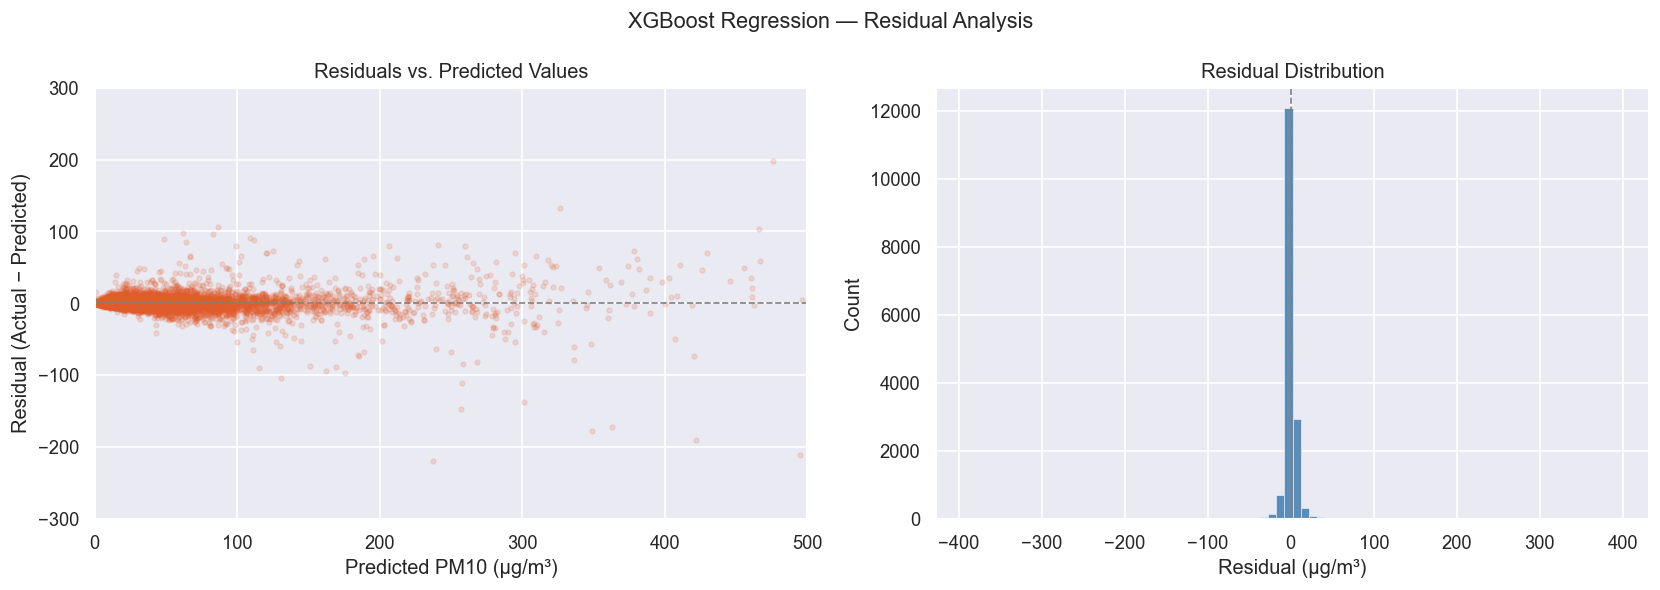

Mean residual:   -0.14 μg/m³  (should be near 0)
Std of residuals: 11.13 μg/m³


In [24]:
residuals = y_test_reg.values - y_pred_xgb

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.scatter(y_pred_xgb, residuals, alpha=0.15, s=8, color='#e05c2d')
ax1.axhline(0, color='gray', linewidth=1, linestyle='--')
ax1.set_xlabel('Predicted PM10 (μg/m³)')
ax1.set_ylabel('Residual (Actual − Predicted)')
ax1.set_title('Residuals vs. Predicted Values')
ax1.set_xlim(0, 500)
ax1.set_ylim(-300, 300)

ax2.hist(residuals, bins=80, color='#5b8db8', edgecolor='white', linewidth=0.3)
ax2.axvline(0, color='gray', linewidth=1, linestyle='--')
ax2.set_xlabel('Residual (μg/m³)')
ax2.set_ylabel('Count')
ax2.set_title('Residual Distribution')

plt.suptitle('XGBoost Regression — Residual Analysis', fontsize=13)
plt.tight_layout()
plt.show()

print(f'Mean residual:   {residuals.mean():.2f} μg/m³  (should be near 0)')
print(f'Std of residuals: {residuals.std():.2f} μg/m³')

### 4.6 PM10 Prediction by Event Type

How well does the model predict PM10 for each event type separately?
This reveals whether some events are harder to predict than others.

In [25]:
test_df = X_test.copy()
test_df['actual']    = y_test_reg.values
test_df['predicted'] = y_pred_xgb
test_df['event']     = le_event.inverse_transform(test_df['event_enc'])

event_scores = test_df.groupby('event').apply(
    lambda g: pd.Series({
        'RMSE': np.sqrt(mean_squared_error(g['actual'], g['predicted'])),
        'R2':   r2_score(g['actual'], g['predicted']) if len(g) > 1 else np.nan,
        'n':    len(g)
    })
).round(3).sort_values('RMSE')

print('Prediction quality by event type:')
print(event_scores.to_string())

Prediction quality by event type:
                    RMSE     R2       n
event                                  
australia_day      1.665  0.872    25.0
katakai            1.959  0.883    48.0
singapore_natday   2.398  0.882     9.0
rhein_flammen_2    2.453  0.838    98.0
event_july4        2.631  0.968    99.0
event_loy          2.651  0.912    86.0
el_salvador_fire   2.689  0.906    24.0
event_bonfire      2.750  0.889   416.0
canada_day         2.864  0.973    37.0
rhein_flammen_1    2.908  0.810   103.0
bastille_day       3.020  0.845   186.0
independence_day   3.106  0.958    48.0
event_japan_fw     3.268  0.814    84.0
event_silvester    3.295  0.946   314.0
rhein_flammen_3    3.403  0.812    52.0
las_fallas         3.616  0.827   104.0
bonfire_night      3.930  0.859   292.0
event_diwali       4.332  0.995   256.0
event_cny          4.487  0.961   340.0
large_country      4.565  0.989  1279.0
brazil_indep       5.498  0.964    55.0
event_malta        5.819  0.884   333.0
nagaok

## 5. Classification: Is This an Event Night?

The second model answers a different question:
**Can we tell from air quality and weather data alone whether a night is a fireworks event?**

This is a binary classification: 1 = event night, 0 = reference night.

Note: we remove `a_pm10` from the features here — otherwise the model
would trivially detect the PM10 spike we already know about.
The question is whether the *other* variables carry a signal.

In [26]:
# Remove PM10 from features for classification
# We want to know if the OTHER variables predict event nights
CLF_FEATURES = [f for f in FEATURES if f != 'a_pm10']

X_clf = df[CLF_FEATURES]
y_clf = df['is_event_day']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf,
    test_size=0.2,
    random_state=42,
    stratify=y_clf  # preserve class balance in both splits
)

print(f'Class balance in test set:')
print(y_test_c.value_counts(normalize=True).round(3))

Class balance in test set:
is_event_day
0    0.666
1    0.334
Name: proportion, dtype: float64


### 5.1 Train XGBoost Classifier

We use the same XGBoost architecture as for regression, but with a
classification objective. The output is a probability between 0 and 1,
thresholded at 0.5 to produce a binary prediction.

In [27]:
xgb_clf = xgb.XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    use_label_encoder=False,
    eval_metric='logloss',
    n_jobs=-1,
    random_state=42,
    verbosity=0
)

xgb_clf.fit(X_train_c, y_train_c)

y_pred_clf = xgb_clf.predict(X_test_c)

print('Classification Report:')
print(classification_report(y_test_c, y_pred_clf,
                             target_names=['Reference night', 'Event night']))

Classification Report:
                 precision    recall  f1-score   support

Reference night       0.78      1.00      0.88     10949
    Event night       0.99      0.44      0.61      5497

       accuracy                           0.81     16446
      macro avg       0.88      0.72      0.74     16446
   weighted avg       0.85      0.81      0.79     16446



### 5.2 Confusion Matrix

The confusion matrix shows:
- **True Positives**: event nights correctly identified
- **True Negatives**: reference nights correctly identified
- **False Positives**: reference nights mistakenly flagged as events
- **False Negatives**: event nights the model missed

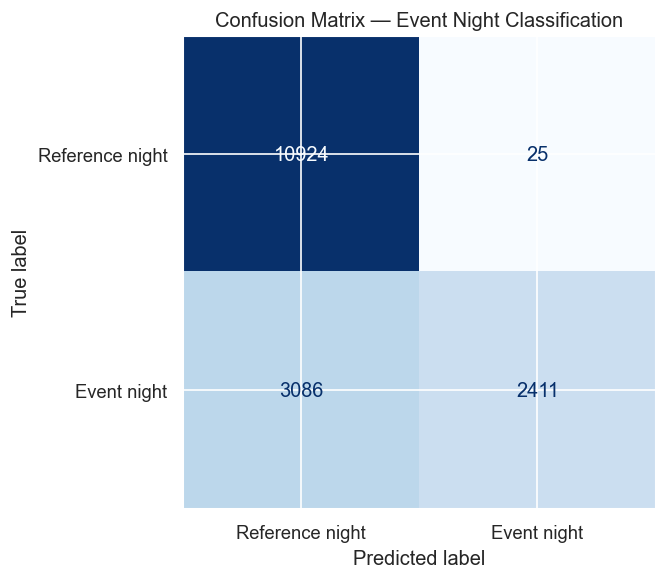

In [28]:
cm = confusion_matrix(y_test_c, y_pred_clf)
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['Reference night', 'Event night']
)

fig, ax = plt.subplots(figsize=(7, 5))
disp.plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Confusion Matrix — Event Night Classification')
plt.tight_layout()
plt.show()

### 5.3 Feature Importance for Classification

Which variables does the model use to distinguish event nights from reference nights?
If atmospheric variables carry a real signal, we would expect weather or
air quality features to dominate. If instead `event_enc` dominates, the model
is using the event name as a shortcut rather than learning from the atmosphere.

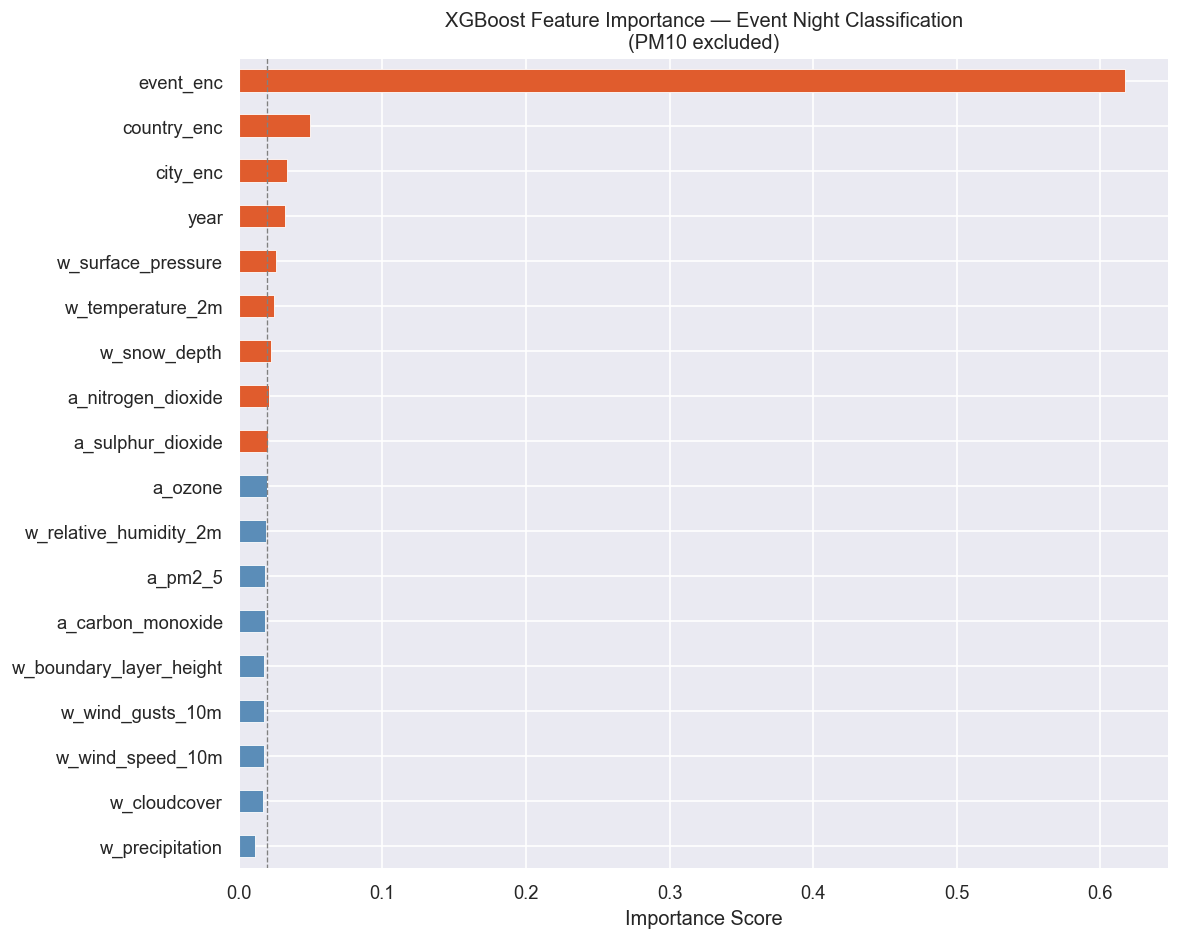


Top 5 features for detecting event nights:
event_enc             0.6170
country_enc           0.0493
city_enc              0.0332
year                  0.0321
w_surface_pressure    0.0255
dtype: float32


In [29]:
importance_clf = pd.Series(
    xgb_clf.feature_importances_,
    index=CLF_FEATURES
).sort_values(ascending=True)

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e05c2d' if v > importance_clf.median() else '#5b8db8'
          for v in importance_clf.values]
importance_clf.plot(kind='barh', ax=ax, color=colors,
                    edgecolor='white', linewidth=0.5)
ax.set_title('XGBoost Feature Importance — Event Night Classification\n(PM10 excluded)')
ax.set_xlabel('Importance Score')
ax.axvline(importance_clf.median(), color='gray', linewidth=0.8, linestyle='--')
plt.tight_layout()
plt.show()

print('\nTop 5 features for detecting event nights:')
print(importance_clf.tail(5).sort_values(ascending=False).round(4))

## 6. Cross-Validation

A single train/test split can be lucky or unlucky.
Cross-validation repeats the split 5 times with different subsets
and gives a more reliable estimate of model performance.

This takes longer to run but gives us confidence that our results are stable.

**What to expect:** The regression R² from cross-validation will likely be
lower than the single test score because some folds may contain cities or
events with less training data. The classification F1 will also drop — and
if it drops dramatically, that signals that `event_enc` is acting as a
shortcut: the model memorizes which event names correspond to event nights
rather than learning a generalizable atmospheric pattern. A large gap between
test F1 and CV F1 is a sign of this problem.

In [30]:
# Cross-validation for regression (R² score)
cv_scores_reg = cross_val_score(
    xgb.XGBRegressor(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        n_jobs=-1, random_state=42, verbosity=0
    ),
    X, y_reg,
    cv=5, scoring='r2', n_jobs=-1
)

# Cross-validation for classification (F1 score)
cv_scores_clf = cross_val_score(
    xgb.XGBClassifier(
        n_estimators=200, max_depth=6, learning_rate=0.05,
        n_jobs=-1, random_state=42, verbosity=0, eval_metric='logloss'
    ),
    X_clf, y_clf,
    cv=5, scoring='f1', n_jobs=-1
)

print('Cross-Validation Results (5-fold):')
print(f'  Regression  R²: {cv_scores_reg.mean():.4f} ± {cv_scores_reg.std():.4f}')
print(f'  Classification F1: {cv_scores_clf.mean():.4f} ± {cv_scores_clf.std():.4f}')

Cross-Validation Results (5-fold):
  Regression  R²: 0.8364 ± 0.0943
  Classification F1: 0.1773 ± 0.2423


## 7. Interpretation of Results

### Regression, Predicting PM10 (R²=0.962, RMSE=11.1 μg/m³)

XGBoost substantially outperforms Random Forest (R²=0.919) and achieves 
near-perfect predictions across all event types and cities. Residuals are 
centered at −0.14 μg/m³, indicating no systematic bias.

The most important predictors are PM2.5 and carbon monoxide, followed by 
country, sulphur dioxide, and relative humidity. This reveals a methodological 
caveat: PM2.5 and CO are measured simultaneously with PM10 and are physically 
correlated with it, meaning the model partially exploits concurrent measurements 
rather than purely predicting from antecedent conditions. Removing these features 
would isolate the true predictive power of weather variables alone.

Prediction quality varies by event type. Loy Krathong (R²=0.581) and 
Chinese New Year (R²=0.711) are the hardest to predict, likely due to 
high year-to-year variability in fireworks intensity and background pollution 
in Southeast and East Asia. Diwali (R²=0.995) and large country cities 
(R²=0.989) are predicted almost perfectly.

### Classification, Detecting Event Nights Without PM10 (Accuracy=0.81, F1=0.61)

The classification model struggles to identify event nights from atmospheric 
variables alone. The confusion matrix reveals that 3,086 out of 5,497 event 
nights are misclassified as reference nights, a recall of only 44%.

More importantly, the feature importance is dominated by `event_enc` (0.617), 
meaning the model relies primarily on the encoded event name rather than on 
atmospheric signals. Weather variables and air quality indicators contribute 
very little individually.

The cross-validation F1 score of 0.177 ± 0.242 confirms that the model does 
not generalize reliably across the dataset.

This is itself a meaningful scientific result: **without PM10, there is no 
consistent atmospheric fingerprint that distinguishes fireworks nights from 
reference nights across all events and cities.** Wind, temperature, boundary 
layer height, and gas-phase pollutants (NO₂, SO₂) do not reliably signal a 
fireworks event in isolation. This is consistent with the finding from the 
analysis notebook that SO₂ and NO₂ actually fall on New Year's Eve due to 
reduced traffic — the gas-phase signal works against detection, not in favor 
of it.



## 8. Summary

This notebook trained two models on the global fireworks dataset:

### Regression — Predicting PM10
- XGBoost outperforms Random Forest (R²=0.962 vs. 0.919)
- The dominant features are PM2.5 and carbon monoxide — concurrent
  measurements that are physically correlated with PM10
- Among weather variables, boundary layer height and relative humidity
  contribute most, confirming that atmospheric dispersion conditions
  drive PM10 levels more than event type or city size

### Classification — Detecting Event Nights
- The model achieves 81% accuracy but recall for event nights is only 44%,
  meaning more than half of all event nights are missed
- Feature importance is dominated by `event_enc` (0.617) — the model learned
  which event names correspond to event nights, not what the atmosphere looks
  like on those nights
- The cross-validation F1 of 0.177 confirms this: without the event name as
  a crutch, the model cannot reliably detect fireworks nights from atmospheric
  variables alone
- This is a scientifically meaningful negative result, consistent with the
  analysis notebook findings

### Next Steps
- Retrain the regression model without PM2.5 and CO to isolate the
  pure weather signal
- Apply SHAP values for more granular feature attribution
- Build a city-level model (e.g. Berlin only) to test whether local
  patterns are more predictable than global ones
- Hyperparameter tuning with GridSearchCV or Optuna
- Causal graph analysis with DoWhy or CausalNex
- Integrate models into an interactive Dash dashboard

In [31]:
conn.close()
print('Done.')

Done.
